---
title: "Лабораторна робота 7. Методи кластеризації (навчання без учителя)"
description:
  __Розпізнавання образів та комп'ютерний зір__
author: Denys Harahulia
date: "04.07.2026"
lang: ukr
format:
  html:
    code-fold: true
    toc: true # меню
    toc_float: # спливаюче меню  
      collapsed: true # авто
      number_sections: true
jupyter: python3
---

**Мета**: закріпити на практиці концепцію алгоритмів кластеризації k-means, DBSCAN та агломеративних засобами мови Python

## Завдання для самостійної роботи 

1. Розглянути наведені вище приклади.
1. Реалізувати всі алгоритми кластеризації, наведені в роботі, для свого варіанта, обгрунтувавши значення відповідних параметрів.
1. Дати відповіді на контрольні запитання.
1. Відправити результати роботи у файлі lab_7_StudentLastName.ipynb до віддаленого репозиторію на GіtHub

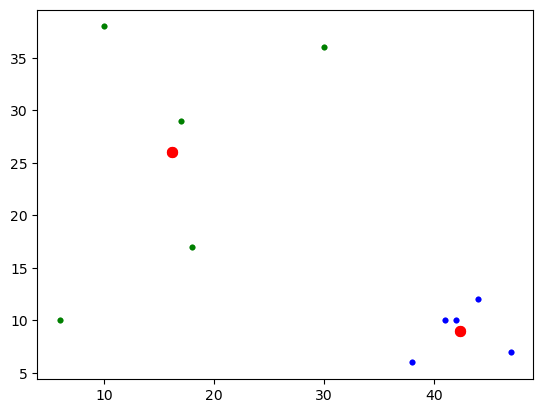

In [18]:
# Алгоритм Ллойда (метод K-середніх для кластеризації)
import time

import numpy as np
import matplotlib.pyplot as plt

x = [(17, 29), (44, 12), (47, 7), (18, 17), (30, 36), (6, 10), (38, 6), (10, 38), (41, 10), (42, 10)]

# x = [(64, 150), (84, 112), (106, 90), (154, 64), (192, 62), (220, 82), (244, 92), (271, 111), (275, 137), (286, 161), (56, 178), (80, 156), (101, 131), (123, 104), (155, 94), (191, 100), (242, 70), (231, 114), (272, 95), (261, 131), (299, 136), (308, 124), (128, 78), (47, 128), (47, 159), (137, 186), (166, 228), (171, 250), (194, 272), (221, 287), (253, 292), (308, 293), (332, 280), (385, 256), (398, 237), (413, 205), (435, 166), (447, 137), (422, 126), (400, 154), (389, 183), (374, 214), (358, 235), (321, 250), (274, 263), (249, 263), (208, 230), (192, 204), (182, 174), (147, 205), (136, 246), (147, 255), (182, 282), (204, 298), (252, 316), (312, 321), (349, 313), (393, 288), (417, 259), (434, 222), (443, 187), (463, 174)]
# x = [(126, 63), (101, 100), (80, 160), (88, 208), (89, 282), (88, 362), (94, 406), (149, 377), (147, 304), (147, 235), (146, 152), (160, 103), (174, 142), (169, 184), (170, 241), (169, 293), (185, 376), (178, 422), (116, 353), (124, 194), (273, 69), (277, 112), (260, 150), (265, 185), (270, 235), (265, 295), (281, 351), (285, 416), (321, 404), (316, 366), (306, 304), (309, 254), (309, 207), (327, 161), (318, 108), (306, 66), (425, 66), (418, 135), (411, 183), (413, 243), (414, 285), (407, 333), (411, 385), (443, 387), (455, 330), (441, 252), (457, 207), (453, 149), (455, 90), (455, 56), (439, 102), (431, 162), (431, 193), (426, 236), (427, 281), (438, 323), (419, 379), (425, 389), (422, 349), (451, 275), (441, 222), (297, 145), (284, 195), (288, 237), (292, 282), (288, 313), (303, 356), (293, 395), (274, 268), (280, 344), (303, 187), (114, 247), (131, 270), (144, 215), (124, 219), (98, 240), (96, 281), (146, 267), (136, 221), (123, 166), (101, 185), (152, 184), (104, 283), (74, 239), (107, 287), (118, 335), (89, 336), (91, 315), (151, 340), (131, 373), (108, 133), (134, 130), (94, 260), (113, 193)]


M = np.mean(x, axis=0)      # обчислення середніх за кожною координатою
D = np.var(x, axis=0)       # обчислення дисперсій за кожною координатою
K = 2                       # кількість кластерів
ma = [np.random.normal(M, np.sqrt(D / 10), 2) for n in range(K)]        # початкові центри кластерів
# ma = [np.array(x[0]), np.array(x[1])]
ro = lambda x_vect, m_vect: np.mean((x_vect - m_vect) ** 2)             # евклідова метрика

COLORS = ('green', 'blue', 'brown', 'black')     # кількість кольорів повинна бути не менше кількості кластерів (>= K)

plt.ion()
n = 0
while n < 10:
    X = [[] for i in range(K)]                  # ініціалізація порожнього двовимірного списку для зберігання об'єктів кластерів

    for x_vect in x:
        r = [ro(x_vect, m) for m in ma]         # обчислення відстаней для поточного зображення до центрів кластерів
        X[np.argmin(r)].append(x_vect)          # додавання зображення до кластеру з найближчим центром

    ma = [np.mean(xx, axis=0) for xx in X]      # перерахунок центрів кластерів

    plt.clf()
    # відображення знайдених кластерів
    for i in range(K):
        xx = np.array(X[i]).T
        plt.scatter(xx[0], xx[1], s=10, color=COLORS[i])

    # відображення центрів кластерів
    mx = [m[0] for m in ma]
    my = [m[1] for m in ma]
    plt.scatter(mx, my, s=50, color='red')

    plt.draw()
    plt.gcf().canvas.flush_events()
#    plt.savefig(f"lloyd {n+1}.png")
    time.sleep(0.2)

    n += 1

plt.ioff()

# відображення знайдених кластерів
for i in range(K):
    xx = np.array(X[i]).T
    plt.scatter(xx[0], xx[1], s=10, color=COLORS[i])

# відображення центрів кластерів
mx = [m[0] for m in ma]
my = [m[1] for m in ma]
plt.scatter(mx, my, s=50, color='red')

plt.show()

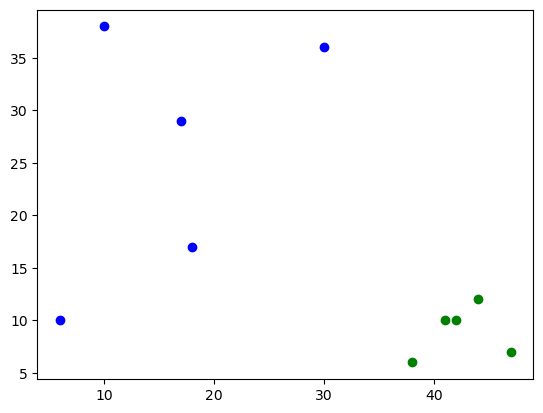

In [22]:
# Алгоритм DBSCAN, взято з сайту: https://habr.com/ru/post/322034/

from itertools import cycle
from math import hypot
from numpy import random
import matplotlib.pyplot as plt


def dbscan_naive(P, eps, m, distance):
    NOISE = 0
    C = 0

    visited_points = set()
    clustered_points = set()
    clusters = {NOISE: []}

    def region_query(p):
        return [q for q in P if distance(p, q) < eps]

    def expand_cluster(p, neighbours):
        if C not in clusters:
            clusters[C] = []
        clusters[C].append(p)
        clustered_points.add(p)
        while neighbours:
            q = neighbours.pop()
            if q not in visited_points:
                visited_points.add(q)
                neighbourz = region_query(q)
                if len(neighbourz) > m:
                    neighbours.extend(neighbourz)
            if q not in clustered_points:
                clustered_points.add(q)
                clusters[C].append(q)
                if q in clusters[NOISE]:
                    clusters[NOISE].remove(q)

    for p in P:
        if p in visited_points:
            continue
        visited_points.add(p)
        neighbours = region_query(p)
        if len(neighbours) < m:
            clusters[NOISE].append(p)
        else:
            C += 1
            expand_cluster(p, neighbours)

    return clusters


# P = [(98, 62), (80, 95), (71, 130), (89, 164), (137, 115), (107, 155), (109, 105), (174, 62), (183, 115), (164, 153), (142, 174), (140, 80), (308, 123), (229, 171), (195, 237), (180, 298), (179, 340), (251, 262), (300, 176), (346, 178), (311, 237), (291, 283), (254, 340), (215, 308), (239, 223), (281, 207), (283, 156)]
# P = [(126, 63), (101, 100), (80, 160), (88, 208), (89, 282), (88, 362), (94, 406), (149, 377), (147, 304), (147, 235), (146, 152), (160, 103), (174, 142), (169, 184), (170, 241), (169, 293), (185, 376), (178, 422), (116, 353), (124, 194), (273, 69), (277, 112), (260, 150), (265, 185), (270, 235), (265, 295), (281, 351), (285, 416), (321, 404), (316, 366), (306, 304), (309, 254), (309, 207), (327, 161), (318, 108), (306, 66), (425, 66), (418, 135), (411, 183), (413, 243), (414, 285), (407, 333), (411, 385), (443, 387), (455, 330), (441, 252), (457, 207), (453, 149), (455, 90), (455, 56), (439, 102), (431, 162), (431, 193), (426, 236), (427, 281), (438, 323), (419, 379), (425, 389), (422, 349), (451, 275), (441, 222), (297, 145), (284, 195), (288, 237), (292, 282), (288, 313), (303, 356), (293, 395), (274, 268), (280, 344), (303, 187), (114, 247), (131, 270), (144, 215), (124, 219), (98, 240), (96, 281), (146, 267), (136, 221), (123, 166), (101, 185), (152, 184), (104, 283), (74, 239), (107, 287), (118, 335), (89, 336), (91, 315), (151, 340), (131, 373), (108, 133), (134, 130), (94, 260), (113, 193)]
P = [(17, 29), (44, 12), (47, 7), (18, 17), (30, 36), (6, 10), (38, 6), (10, 38), (41, 10), (42, 10)]

# Розмір епсилон-околу
eps = 10    
# Мінімальна кількість об'єктів для повного епсилон-околу
m = 5       

clusters = dbscan_naive(P, eps, m, lambda x, y: hypot(x[0] - y[0], x[1] - y[1]))
for c, points in zip(cycle('bgrcmykgrcmykgrcmykgrcmykgrcmykgrcmyk'), clusters.values()):
    X = [p[0] for p in points]
    Y = [p[1] for p in points]
    plt.scatter(X, Y, c=c)
plt.show()

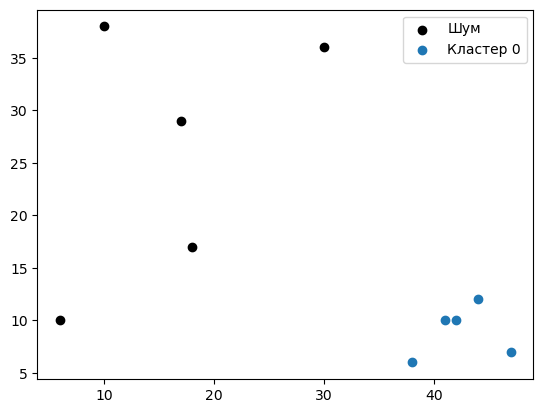

In [23]:
# Алгоритм DBSCAN засобами scikit-learn

from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# Дані
P = np.array([(17, 29), (44, 12), (47, 7), (18, 17), (30, 36), (6, 10), (38, 6), (10, 38), (41, 10), (42, 10)])

# Розмір епсилон-околу
eps = 10    
# Мінімальна кількість об'єктів для повного епсилон-околу
m = 5   

# Використання алгоритму DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=m)
dbscan.fit(P)
labels = dbscan.labels_

# Вивід кластерів
unique_labels = np.unique(labels)
for label in unique_labels:
    if label == -1:
        plt.scatter(P[labels == label][:, 0], P[labels == label][:, 1], color='k', label='Шум')
    else:
        plt.scatter(P[labels == label][:, 0], P[labels == label][:, 1], label=f'Кластер {label}')

plt.legend()
plt.show()

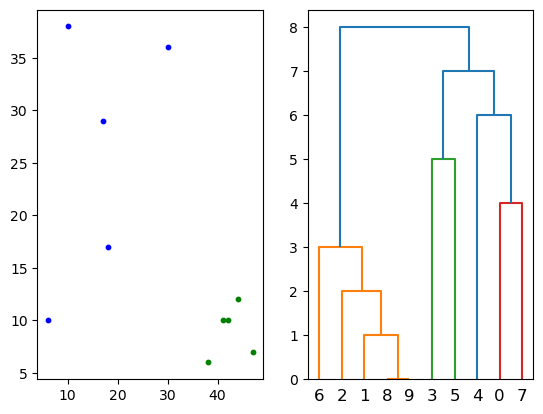

In [21]:
# Агломеративна ієрархічна кластеризація за допомогою пакету Sk-Learn

from itertools import cycle
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt


# функція для відображення дендрограми (взято з репозиторію sklearn)
def plot_dendrogram(model, **kwargs):

    # Діти ієрархічної кластеризації
    children = model.children_

    # Відстані між кожною парою дітей
    # Оскільки у нас немає цієї інформації, ми можемо використовувати рівномірну для відображення
    distance = np.arange(children.shape[0])

    # Кількість спостережень у кожному рівні кластеру
    no_of_observations = np.arange(2, children.shape[0]+2)

    # Створення матриці зв'язків, а потім побудова дендрограми
    linkage_matrix = np.column_stack([children, distance, no_of_observations]).astype(float)

    # Побудова відповідної дендрограми
    dendrogram(linkage_matrix, **kwargs)


# вхідні зображення для кластеризації
x = [(17, 29), (44, 12), (47, 7), (18, 17), (30, 36), (6, 10), (38, 6), (10, 38), (41, 10), (42, 10)]
x = np.array(x)

NC = 2      # максимальна кількість кластерів (кінцевих)

# агломеративна ієрархічна кластеризація
clustering = AgglomerativeClustering(n_clusters=NC, linkage="ward")
x_pr = clustering.fit_predict(x)

# відображення результату кластеризації та дендрограми
f, ax = plt.subplots(1, 2)
for c, n in zip(cycle('bgrcmykgrcmykgrcmykgrcmykgrcmykgrcmyk'), range(NC)):
    clst = x[x_pr == n].T
    ax[0].scatter(clst[0], clst[1], s=10, color=c)

plot_dendrogram(clustering, ax=ax[1])
plt.show()